# Agentic Multi-Agent Research Assistant for Document AI

This notebook builds an end-to-end **agentic RAG research assistant** for answering technical questions over local PDFs and recent arXiv papers in document AI. It combines layout-aware document ingestion, hybrid retrieval, a LangGraph reasoning workflow, contradiction checks, and an NLI-based hallucination guard.

## Project Goals

- Ingest local PDFs and arXiv papers into a reusable research corpus.
- Preserve document structure with layout-block extraction before chunking.
- Retrieve evidence using both dense semantic search and sparse keyword search.
- Route answers through a streamlined LangGraph workflow that returns synthesis before asynchronous guard verification.
- Validate generated claims with calibrated NLI plus semantic similarity, using SUPPORTED/PARTIALLY_SUPPORTED/UNVERIFIED statuses.
- Evaluate faithfulness, claim precision, support rate, retry trigger rate, and latency split automatically.
- Provide a Streamlit interface for interactive demos and source inspection.

## System Architecture

1. **Corpus Builder** extracts text from PDFs, fetches arXiv papers, chunks layout blocks, embeds passages, and builds FAISS + BM25 indexes.
2. **Retriever Agent** gathers candidate chunks with hybrid retrieval and Reciprocal Rank Fusion.
3. **Contradiction Detector** highlights tensions across top retrieved sources without requiring generated summaries.
4. **Synthesiser Agent** writes atomic, citation-bearing bullets directly from raw layout-aware chunks.
5. **Async Hallucination Guard** verifies claims after the answer is returned, using NLI plus semantic similarity.
6. **Guard Retry Logic** performs at most one wider retrieval pass, and only when the top-ranked key claims are unverified.

## Runtime Notes

- A Colab T4 GPU is recommended when `LOAD_LLM = True`.
- On CPU-only runtimes, set `LOAD_LLM = False` for a fast extractive dry run.
- Disable `LOAD_NLI` only for quick smoke tests; claim-level faithfulness metrics require it.
- The first run downloads embedding, NLI, LLM, and arXiv assets, so setup can take several minutes.

## Expected Outputs

By the end of the notebook, you should have:

- A searchable PDF + arXiv corpus.
- A LangGraph assistant that returns grounded research answers.
- Tables showing retrieved sources and claim-level support scores.
- An automated evaluation summary across 20 document-AI questions.
- A Streamlit demo app with chat, source display, confidence scores, and export support.


## 1. Install Dependencies

Install the libraries required for retrieval, graph orchestration, document parsing, model inference, evaluation, and the Streamlit demo. In Colab, this cell may take a few minutes on the first run.


In [1]:
# Colab setup
# torchvision isn't used anywhere in this notebook (no vision models), and it
# causes a torch/torchvision ABI mismatch crash on Colab when torch gets
# upgraded but torchvision doesn't. Remove it so transformers doesn't try to
# lazily import it.
!pip -q uninstall -y torchvision torchaudio

# Do NOT pin transformers to an old version (e.g. 4.39.x) - Phi-3 was only
# natively merged into transformers in 4.41.0. Anything older forces
# trust_remote_code's custom modeling files, which is what causes the
# "rope_scaling" KeyError/ValueError crash later when loading Phi-3-mini.
!pip -q install -U \
  langchain langchain-community langgraph \
  faiss-cpu sentence-transformers pymupdf streamlit requests arxiv \
  "transformers>=4.44" accelerate sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.9/136.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.5/247.5 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.3/558.3 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 M

## 2. Configure the Runtime

Set the corpus location, arXiv search scope, and model-loading flags before building the assistant. These values control the cost and speed of the notebook.

| Setting | Purpose |
| --- | --- |
| `PDF_FOLDER` | Folder containing local PDFs to index. |
| `ARXIV_QUERY` | Search phrase used to fetch additional research papers. |
| `ARXIV_MAX_RESULTS` | Maximum number of arXiv papers to download. |
| `LOAD_LLM` | Enables Phi-3 generation; turn off for CPU-only dry runs. |
| `LOAD_NLI` | Enables entailment-based grounding checks and faithfulness metrics. |


In [2]:
# Runtime configuration
import os
import torch

PDF_FOLDER = "/content/pdfs"
ARXIV_QUERY = "document layout understanding"
ARXIV_MAX_RESULTS = 20

# Set False on CPU-only Colab for a quick dry run without downloading Phi-3.
LOAD_LLM = True

# NLI is smaller than Phi-3 but still downloads a model. Disable for fastest smoke tests.
LOAD_NLI = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs(PDF_FOLDER, exist_ok=True)
print("Device:", DEVICE)
print("PDF folder:", PDF_FOLDER)

Device: cuda
PDF folder: /content/pdfs


## 3. Write the Core Research Assistant Module

This cell creates `research_assistant_core.py`, which contains the reusable implementation for ingestion, indexing, retrieval, graph execution, hallucination checking, and evaluation.

Key components included in the module:

- Layout-aware PDF extraction with PyMuPDF.
- Block-preserving chunk construction with a fallback for oversized blocks.
- Dense embeddings using `sentence-transformers/all-MiniLM-L6-v2`.
- Sparse BM25-style ranking and FAISS vector search.
- Reciprocal Rank Fusion for hybrid retrieval.
- LangGraph nodes for retrieval, contradiction detection, and raw-evidence synthesis.
- Optional parallel document summarisation outside the blocking answer path.
- An asynchronous calibrated hallucination guard with one capped retrieval retry for failed top claims.
- A 20-question evaluation set with latency split, support-rate, precision, and retry metrics.


In [3]:
%%writefile research_assistant_core.py
from __future__ import annotations

import math
import os
import re
import tempfile
import time
from collections import Counter, defaultdict
from concurrent.futures import Future, ThreadPoolExecutor
from dataclasses import dataclass
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple, TypedDict

import arxiv
import faiss
import fitz
import numpy as np
import requests
import torch
from langgraph.graph import END, StateGraph
from sentence_transformers import SentenceTransformer
from transformers import (
    AutoModelForCausalLM,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    pipeline,
)


def clean_text(text: str) -> str:
    text = re.sub(r"\s+", " ", text or "").strip()
    return text


def word_tokenize(text: str) -> List[str]:
    return re.findall(r"[a-zA-Z0-9][a-zA-Z0-9\-_/]+", (text or "").lower())


def safe_year(value: Any) -> Optional[int]:
    if value is None:
        return None
    match = re.search(r"(19|20)\d{2}", str(value))
    return int(match.group(0)) if match else None


def first_sentence(text: str, fallback_words: int = 36) -> str:
    text = clean_text(text)
    parts = re.split(r"(?<=[.!?])\s+", text)
    for part in parts:
        if len(part.split()) >= 5:
            return part.strip()
    return " ".join(text.split()[:fallback_words]).strip()


@dataclass
class ChunkRecord:
    text: str
    paper_title: str
    authors: str
    year: Optional[int]
    chunk_id: str
    source_url: str

    @property
    def metadata(self) -> Dict[str, Any]:
        return {
            "paper_title": self.paper_title,
            "authors": self.authors,
            "year": self.year,
            "chunk_id": self.chunk_id,
            "source_url": self.source_url,
        }


class SimpleBM25:
    """Small dependency-free BM25 implementation for Colab notebooks."""

    def __init__(self, texts: Sequence[str], k1: float = 1.5, b: float = 0.75):
        self.k1 = k1
        self.b = b
        self.docs = [word_tokenize(t) for t in texts]
        self.n_docs = len(self.docs)
        self.avgdl = sum(len(d) for d in self.docs) / max(1, self.n_docs)
        self.doc_freq: Counter[str] = Counter()
        self.term_freqs: List[Counter[str]] = []

        for doc in self.docs:
            tf = Counter(doc)
            self.term_freqs.append(tf)
            self.doc_freq.update(tf.keys())

        self.idf = {
            term: math.log(1 + (self.n_docs - df + 0.5) / (df + 0.5))
            for term, df in self.doc_freq.items()
        }

    def get_scores(self, query: str) -> np.ndarray:
        query_terms = word_tokenize(query)
        scores = np.zeros(self.n_docs, dtype=np.float32)
        for i, tf in enumerate(self.term_freqs):
            dl = len(self.docs[i]) or 1
            score = 0.0
            for term in query_terms:
                if term not in tf:
                    continue
                freq = tf[term]
                denom = freq + self.k1 * (1 - self.b + self.b * dl / max(self.avgdl, 1e-6))
                score += self.idf.get(term, 0.0) * (freq * (self.k1 + 1) / denom)
            scores[i] = score
        return scores


class CorpusBuilder:
    """Builds a PDF/arXiv corpus, dense FAISS index, and sparse BM25 index."""

    def __init__(
        self,
        embedding_model: str = "sentence-transformers/all-MiniLM-L6-v2",
        chunk_tokens: int = 300,
        overlap_tokens: int = 50,
        device: Optional[str] = None,
    ):
        self.embedding_model = embedding_model
        self.chunk_tokens = chunk_tokens
        self.overlap_tokens = overlap_tokens
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.embedder = SentenceTransformer(embedding_model, device=self.device)
        self.chunk_tokenizer = AutoTokenizer.from_pretrained(embedding_model)
        self.chunks: List[ChunkRecord] = []
        self.faiss_index: Optional[faiss.Index] = None
        self.embeddings: Optional[np.ndarray] = None
        self.bm25: Optional[SimpleBM25] = None

    def _sliding_window_chunk(self, text: str) -> List[str]:
        """Fallback blind token-window chunker, used only when a single layout
        block is larger than chunk_tokens (e.g. a dense paragraph with no
        sub-structure PyMuPDF can split on)."""
        token_ids = self.chunk_tokenizer.encode(text, add_special_tokens=False)
        step = max(1, self.chunk_tokens - self.overlap_tokens)
        chunks = []
        for start in range(0, len(token_ids), step):
            window = token_ids[start : start + self.chunk_tokens]
            if len(window) < 40:
                continue
            chunks.append(self.chunk_tokenizer.decode(window, skip_special_tokens=True))
        return chunks

    def _chunk_text(self, text: str) -> List[str]:
        """Blind fallback chunker for plain text with no layout info (e.g.
        arXiv abstracts). Prefer _chunk_blocks when layout blocks are available."""
        text = clean_text(text)
        if not text:
            return []
        return self._sliding_window_chunk(text)

    def _chunk_blocks(self, blocks: List[str]) -> List[str]:
        """Layout-aware chunking: pack consecutive PyMuPDF text blocks (paragraphs,
        headings, table cells) into windows up to chunk_tokens, so we never split a
        paragraph in the middle of a sentence the way a blind sliding window does.
        A block is only forced through the sliding-window fallback if it alone
        exceeds chunk_tokens (e.g. a long unbroken paragraph)."""
        chunks: List[str] = []
        current_blocks: List[str] = []
        current_tokens = 0

        def flush():
            if current_blocks:
                chunks.append(clean_text("\n".join(current_blocks)))

        for block in blocks:
            block = clean_text(block)
            if not block:
                continue
            block_tokens = len(self.chunk_tokenizer.encode(block, add_special_tokens=False))

            if block_tokens > self.chunk_tokens:
                # Oversized single block: flush what we have, then sliding-window
                # just this block on its own.
                flush()
                current_blocks, current_tokens = [], 0
                chunks.extend(self._sliding_window_chunk(block))
                continue

            if current_tokens + block_tokens > self.chunk_tokens and current_blocks:
                flush()
                # carry the last block forward as overlap context
                current_blocks = [current_blocks[-1]] if self.overlap_tokens > 0 else []
                current_tokens = (
                    len(self.chunk_tokenizer.encode(current_blocks[0], add_special_tokens=False))
                    if current_blocks
                    else 0
                )

            current_blocks.append(block)
            current_tokens += block_tokens

        flush()
        return [c for c in chunks if len(c.split()) >= 8]

    def _extract_pdf_blocks(self, path: Optional[str] = None, pdf_bytes: Optional[bytes] = None, max_pages: Optional[int] = None) -> List[str]:
        """Extract text as an ordered list of layout blocks (paragraphs/headings/
        table cells) using PyMuPDF's block-level extraction, instead of flattening
        the whole document to one plain-text blob. Blocks are sorted in reading
        order (top-to-bottom, left-to-right) per page."""
        if path:
            doc = fitz.open(path)
        else:
            doc = fitz.open(stream=pdf_bytes, filetype="pdf")
        page_count = len(doc) if max_pages is None else min(max_pages, len(doc))
        blocks: List[str] = []
        for i in range(page_count):
            page_blocks = doc[i].get_text("blocks")  # (x0, y0, x1, y1, text, block_no, block_type)
            # sort by (y0, x0) for reading order; skip image blocks (type != 0)
            page_blocks = sorted(
                (b for b in page_blocks if len(b) >= 7 and b[6] == 0),
                key=lambda b: (round(b[1], 1), b[0]),
            )
            for b in page_blocks:
                text = clean_text(b[4])
                if text:
                    blocks.append(text)
        doc.close()
        return blocks

    def _extract_pdf_text(self, path: Optional[str] = None, pdf_bytes: Optional[bytes] = None, max_pages: Optional[int] = None) -> str:
        """Kept for callers that only need flat text (e.g. length comparisons)."""
        return clean_text("\n".join(self._extract_pdf_blocks(path=path, pdf_bytes=pdf_bytes, max_pages=max_pages)))

    def _pdf_metadata(self, path: str) -> Dict[str, Any]:
        doc = fitz.open(path)
        meta = doc.metadata or {}
        doc.close()
        title = clean_text(meta.get("title") or "") or os.path.splitext(os.path.basename(path))[0]
        authors = clean_text(meta.get("author") or "") or "Unknown"
        year = safe_year(meta.get("creationDate") or meta.get("modDate"))
        return {"paper_title": title, "authors": authors, "year": year, "source_url": path}

    def _add_document(self, text: str = "", metadata: Dict[str, Any] = None, blocks: Optional[List[str]] = None) -> int:
        metadata = metadata or {}
        pieces = self._chunk_blocks(blocks) if blocks else self._chunk_text(text)
        before = len(self.chunks)
        safe_title = metadata.get("paper_title") or "Untitled"
        for i, chunk in enumerate(pieces):
            chunk_id = f"{safe_title[:48]}::{before + i}"
            self.chunks.append(
                ChunkRecord(
                    text=chunk,
                    paper_title=safe_title,
                    authors=metadata.get("authors") or "Unknown",
                    year=metadata.get("year"),
                    chunk_id=chunk_id,
                    source_url=metadata.get("source_url") or "",
                )
            )
        return len(self.chunks) - before

    def add_pdf_folder(self, folder: str, max_pages: Optional[int] = None) -> int:
        added = 0
        if not os.path.isdir(folder):
            return 0
        for name in sorted(os.listdir(folder)):
            if not name.lower().endswith(".pdf"):
                continue
            path = os.path.join(folder, name)
            try:
                metadata = self._pdf_metadata(path)
                blocks = self._extract_pdf_blocks(path=path, max_pages=max_pages)
                added += self._add_document(metadata=metadata, blocks=blocks)
            except Exception as exc:
                print(f"Skipping {path}: {exc}")
        return added

    def fetch_arxiv(
        self,
        query: str = "document layout understanding",
        max_results: int = 20,
        download_pdfs: bool = True,
        max_pages: Optional[int] = 12,
        request_timeout: int = 45,
    ) -> int:
        added = 0
        client = arxiv.Client(page_size=min(max_results, 50), delay_seconds=3, num_retries=3)
        search = arxiv.Search(
            query=query,
            max_results=max_results,
            sort_by=arxiv.SortCriterion.Relevance,
        )
        for result in client.results(search):
            metadata = {
                "paper_title": clean_text(result.title),
                "authors": ", ".join(str(a) for a in result.authors),
                "year": result.published.year if result.published else None,
                "source_url": result.entry_id,
            }
            text = clean_text(result.summary)
            blocks: Optional[List[str]] = None
            if download_pdfs and result.pdf_url:
                try:
                    response = requests.get(result.pdf_url, timeout=request_timeout)
                    response.raise_for_status()
                    pdf_blocks = self._extract_pdf_blocks(pdf_bytes=response.content, max_pages=max_pages)
                    if sum(len(b) for b in pdf_blocks) > len(text):
                        blocks = pdf_blocks
                except Exception as exc:
                    print(f"Using abstract only for {result.title}: {exc}")
            added += self._add_document(text=text, metadata=metadata, blocks=blocks)
        return added

    def build_index(self, batch_size: int = 64) -> None:
        if not self.chunks:
            raise ValueError("No chunks found. Add PDFs or fetch arXiv papers first.")
        texts = [c.text for c in self.chunks]
        embeddings = self.embedder.encode(
            texts,
            batch_size=batch_size,
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=True,
        ).astype("float32")
        self.embeddings = embeddings
        self.faiss_index = faiss.IndexFlatIP(embeddings.shape[1])
        self.faiss_index.add(embeddings)
        self.bm25 = SimpleBM25(texts)

    def hybrid_search(
        self,
        query: str,
        top_k: int = 8,
        dense_pool: int = 60,
        sparse_pool: int = 60,
        rrf_k: int = 60,
    ) -> List[Dict[str, Any]]:
        if self.faiss_index is None or self.bm25 is None:
            raise ValueError("Call build_index() before searching.")
        n = len(self.chunks)
        query_vec = self.embedder.encode([query], convert_to_numpy=True, normalize_embeddings=True).astype("float32")
        dense_scores, dense_ids = self.faiss_index.search(query_vec, min(dense_pool, n))
        dense_ids = [int(i) for i in dense_ids[0] if i >= 0]
        dense_score_map = {idx: float(score) for idx, score in zip(dense_ids, dense_scores[0])}

        sparse_scores = self.bm25.get_scores(query)
        sparse_ids = np.argsort(-sparse_scores)[: min(sparse_pool, n)].tolist()

        fused: Dict[int, float] = defaultdict(float)
        for rank, idx in enumerate(dense_ids):
            fused[idx] += 1.0 / (rrf_k + rank + 1)
        for rank, idx in enumerate(sparse_ids):
            fused[idx] += 1.0 / (rrf_k + rank + 1)

        ranked = sorted(fused.items(), key=lambda x: x[1], reverse=True)[:top_k]
        results = []
        for idx, fused_score in ranked:
            chunk = self.chunks[idx]
            results.append(
                {
                    "text": chunk.text,
                    "source": chunk.metadata,
                    "score": float(fused_score),
                    "dense_score": dense_score_map.get(idx, 0.0),
                    "bm25_score": float(sparse_scores[idx]),
                }
            )
        return results


class LocalPhi3LLM:
    """Thin wrapper around microsoft/Phi-3-mini-4k-instruct with a dry-run fallback."""

    def __init__(
        self,
        model_id: str = "microsoft/Phi-3-mini-4k-instruct",
        load_model: bool = True,
        max_new_tokens: int = 512,
    ):
        self.model_id = model_id
        self.load_model = load_model
        self.max_new_tokens = max_new_tokens
        self.generator = None
        self.tokenizer = None
        if load_model:
            self._load()

    def _load(self) -> None:
        dtype = torch.float16 if torch.cuda.is_available() else torch.float32
        # trust_remote_code=False is deliberate: Phi-3 has been natively supported
        # in transformers since 4.41. Using trust_remote_code=True pulls the model
        # repo's own configuration_phi3.py/modeling_phi3.py, which can define a
        # rope_scaling schema that doesn't match whatever transformers version is
        # installed (a common "rope_scaling type" crash). The native implementation
        # is always version-matched to your installed transformers, so this avoids
        # that whole class of bug.
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_id, trust_remote_code=False)
        model_kwargs = {"trust_remote_code": False, "torch_dtype": dtype}
        if torch.cuda.is_available():
            model_kwargs["device_map"] = "auto"
        model = AutoModelForCausalLM.from_pretrained(self.model_id, **model_kwargs)
        self.generator = pipeline(
            "text-generation",
            model=model,
            tokenizer=self.tokenizer,
        )

    def _fallback(self, prompt: str) -> str:
        if "Summarise this paper excerpt" in prompt:
            excerpt = prompt.split(":", 1)[-1]
            return " ".join(re.split(r"(?<=[.!?])\s+", clean_text(excerpt))[:3])
        if "SOURCE PACK" in prompt or "atomic, self-contained claims" in prompt:
            source_lines = [line for line in prompt.splitlines() if line.startswith("Citation:")]
            evidence = []
            for line in source_lines[:8]:
                citation = line.split("Citation:", 1)[-1].strip()
                evidence.append(f"- Retrieved evidence is relevant to the question {citation}")
            evidence_text = "\n".join(evidence) or "- Retrieved sources discuss the query but need LLM synthesis."
            return (
                "[ANSWER]\n"
                "- Retrieved sources provide candidate evidence for the question; enable Phi-3 for a fuller synthesis.\n\n"
                "[EVIDENCE]\n"
                f"{evidence_text}\n\n"
                "[GAPS]\n"
                "- Fallback mode does not infer beyond retrieved excerpts."
            )
        return first_sentence(prompt, fallback_words=80)

    def __call__(self, prompt: str, max_new_tokens: Optional[int] = None) -> str:
        if self.generator is None or self.tokenizer is None:
            return self._fallback(prompt)
        if hasattr(self.tokenizer, "apply_chat_template"):
            messages = [{"role": "user", "content": prompt}]
            prompt_text = self.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        else:
            prompt_text = prompt
        output = self.generator(
            prompt_text,
            max_new_tokens=max_new_tokens or self.max_new_tokens,
            do_sample=False,
            return_full_text=False,
            pad_token_id=self.tokenizer.eos_token_id,
        )[0]["generated_text"]
        return clean_text(output)


class ContradictionDetector:
    """NLI wrapper used for two purposes: (1) cross-paper contradiction detection,
    and (2) claim-vs-source entailment scoring for the hallucination guard.
    Both reuse the same forward pass so we don't load two separate NLI models."""

    def __init__(
        self,
        model_id: str = "cross-encoder/nli-deberta-v3-small",
        load_model: bool = True,
        threshold: float = 0.8,
    ):
        self.model_id = model_id
        self.threshold = threshold
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.tokenizer = None
        self.model = None
        self.contradiction_idx = 0
        self.entailment_idx = 2
        self.neutral_idx = 1
        if load_model:
            self._load()

    def _load(self) -> None:
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_id)
        self.model = AutoModelForSequenceClassification.from_pretrained(self.model_id).to(self.device)
        labels = {int(k): v.lower() for k, v in self.model.config.id2label.items()}
        for idx, label in labels.items():
            if "contrad" in label:
                self.contradiction_idx = idx
            elif "entail" in label:
                self.entailment_idx = idx
            elif "neutral" in label:
                self.neutral_idx = idx

    def _probs(self, premise: str, hypothesis: str) -> Optional[np.ndarray]:
        if self.model is None or self.tokenizer is None:
            return None
        inputs = self.tokenizer(
            premise,
            hypothesis,
            return_tensors="pt",
            truncation=True,
            max_length=512,
        ).to(self.device)
        with torch.no_grad():
            logits = self.model(**inputs).logits[0]
            probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()
        return probs

    def score(self, premise: str, hypothesis: str) -> float:
        probs = self._probs(premise, hypothesis)
        return float(probs[self.contradiction_idx]) if probs is not None else 0.0

    def entailment_score(self, premise: str, hypothesis: str) -> float:
        """P(premise entails hypothesis) - checks whether a *source chunk*
        (premise) actually supports a *generated claim* (hypothesis). This is the
        correct grounding signal, unlike embedding cosine similarity, which only
        measures topical relatedness and can score a contradicting sentence as
        'grounded' if it uses similar vocabulary."""
        probs = self._probs(premise, hypothesis)
        return float(probs[self.entailment_idx]) if probs is not None else 0.0

    def detect(self, claims: Sequence[Dict[str, str]]) -> List[Dict[str, Any]]:
        flags = []
        for i in range(len(claims)):
            for j in range(i + 1, len(claims)):
                if claims[i]["paper_title"] == claims[j]["paper_title"]:
                    continue
                score = max(
                    self.score(claims[i]["key_claim"], claims[j]["key_claim"]),
                    self.score(claims[j]["key_claim"], claims[i]["key_claim"]),
                )
                if score > self.threshold:
                    flags.append(
                        {
                            "paper_a": claims[i]["paper_title"],
                            "claim_a": claims[i]["key_claim"],
                            "paper_b": claims[j]["paper_title"],
                            "claim_b": claims[j]["key_claim"],
                            "score": score,
                            "message": (
                                f"{claims[i]['paper_title']} says {claims[i]['key_claim']}; "
                                f"{claims[j]['paper_title']} says {claims[j]['key_claim']}"
                            ),
                        }
                    )
        return flags


class ResearchState(TypedDict, total=False):
    query: str
    retrieved_chunks: List[Dict[str, Any]]
    paper_summaries: List[Dict[str, Any]]
    contradictions: List[Dict[str, Any]]
    synthesised_answer: str
    final_answer: str
    guard: Dict[str, Any]
    guard_future: Any
    retry_count: int
    timings: Dict[str, float]


class LangGraphResearchAssistant:
    def __init__(
        self,
        corpus: CorpusBuilder,
        load_llm: bool = True,
        load_nli: bool = True,
        top_k: int = 8,
        guard_threshold: float = 0.55,
        partial_threshold: float = 0.35,
        retry_confidence_threshold: float = 0.30,
        max_guard_retries: int = 1,
        guard_max_workers: int = 2,
        summary_max_workers: int = 4,
    ):
        self.corpus = corpus
        self.top_k = top_k
        self.guard_threshold = guard_threshold
        self.partial_threshold = partial_threshold
        self.retry_confidence_threshold = retry_confidence_threshold
        self.max_guard_retries = max_guard_retries
        self.llm = LocalPhi3LLM(load_model=load_llm)
        self.detector = ContradictionDetector(load_model=load_nli)
        self.guard_executor = ThreadPoolExecutor(max_workers=max(1, guard_max_workers))
        self.summary_max_workers = max(1, summary_max_workers)
        self.graph = self._build_graph()

    def _build_graph(self):
        workflow = StateGraph(ResearchState)
        workflow.add_node("RetrieverAgent", self.retriever_agent)
        workflow.add_node("ContradictionDetector", self.contradiction_detector)
        workflow.add_node("SynthesiserAgent", self.synthesiser_agent)
        workflow.set_entry_point("RetrieverAgent")
        workflow.add_edge("RetrieverAgent", "ContradictionDetector")
        workflow.add_edge("ContradictionDetector", "SynthesiserAgent")
        workflow.add_edge("SynthesiserAgent", END)
        return workflow.compile()

    def _should_retry(self, state: ResearchState) -> str:
        """Backward-compatible no-op for old graph visualisations/callers."""
        return "end"

    def retriever_agent(self, state: ResearchState) -> ResearchState:
        start = time.time()
        chunks = self.corpus.hybrid_search(state["query"], top_k=self.top_k)
        timings = dict(state.get("timings", {}))
        timings["retrieval_latency_seconds"] = round(time.time() - start, 3)
        return {"retrieved_chunks": chunks, "retry_count": state.get("retry_count", 0), "timings": timings}

    def _summarise_one_group(self, item: Tuple[str, List[Dict[str, Any]]]) -> Dict[str, Any]:
        title, chunks = item
        meta = chunks[0]["source"]
        excerpt = "\n\n".join(c["text"] for c in chunks)[:4500]
        prompt = (
            "Summarise this paper excerpt in 2-3 factual sentences. Preserve concrete metrics, "
            "dataset names, model names, and limitations when present: "
            f"{excerpt}"
        )
        summary = self.llm(prompt, max_new_tokens=180)
        return {
            "paper_title": title,
            "authors": meta.get("authors"),
            "year": meta.get("year"),
            "source_url": meta.get("source_url"),
            "summary": summary,
            "key_claim": first_sentence(summary),
        }

    def summariser_agent(self, state: ResearchState) -> ResearchState:
        """Optional asynchronous/parallel document summarisation.

        This is deliberately not on the critical Retrieval -> Synthesis path. Call it
        explicitly for document-level notes; synthesis uses raw layout-aware chunks.
        """
        start = time.time()
        grouped: Dict[str, List[Dict[str, Any]]] = defaultdict(list)
        for chunk in state.get("retrieved_chunks", []):
            grouped[chunk["source"]["paper_title"]].append(chunk)
        items = list(grouped.items())
        if not items:
            return {"paper_summaries": []}
        workers = min(len(items), self.summary_max_workers)
        with ThreadPoolExecutor(max_workers=max(1, workers)) as executor:
            summaries = list(executor.map(self._summarise_one_group, items))
        timings = dict(state.get("timings", {}))
        timings["summary_latency_seconds"] = round(time.time() - start, 3)
        return {"paper_summaries": summaries, "timings": timings}

    def _claims_for_contradiction(self, state: ResearchState) -> List[Dict[str, str]]:
        if state.get("paper_summaries"):
            return [
                {"paper_title": s["paper_title"], "key_claim": s.get("key_claim", "")}
                for s in state.get("paper_summaries", [])
                if s.get("key_claim")
            ][:8]

        claims = []
        seen_titles = set()
        for chunk in state.get("retrieved_chunks", []):
            meta = chunk["source"]
            title = meta.get("paper_title") or "Unknown source"
            if title in seen_titles:
                continue
            seen_titles.add(title)
            claim = first_sentence(chunk.get("text", ""), fallback_words=40)
            if claim:
                claims.append({"paper_title": title, "key_claim": claim})
            if len(claims) >= 6:
                break
        return claims

    def contradiction_detector(self, state: ResearchState) -> ResearchState:
        start = time.time()
        claims = self._claims_for_contradiction(state)
        contradictions = self.detector.detect(claims)
        timings = dict(state.get("timings", {}))
        timings["contradiction_latency_seconds"] = round(time.time() - start, 3)
        return {"contradictions": contradictions, "timings": timings}

    def _citation(self, meta: Dict[str, Any]) -> str:
        title = clean_text(str(meta.get("paper_title") or "Unknown paper"))
        year = meta.get("year") or "n.d."
        return f"[{title}, {year}]"

    def _format_chunk_for_prompt(self, chunk: Dict[str, Any], idx: int, max_chars: int = 1200) -> str:
        meta = chunk["source"]
        text = clean_text(chunk.get("text", ""))[:max_chars]
        return (
            f"### Source S{idx}\n"
            f"Citation: {self._citation(meta)}\n"
            f"Paper: {meta.get('paper_title')}\n"
            f"Year: {meta.get('year') or 'n.d.'}\n"
            f"Chunk: {meta.get('chunk_id')}\n"
            f"Retrieval score: {chunk.get('score', 0.0):.4f}\n"
            f"Excerpt: {text}"
        )

    def synthesiser_agent(self, state: ResearchState) -> ResearchState:
        start = time.time()
        chunks = state.get("retrieved_chunks", [])
        source_pack = "\n\n".join(
            self._format_chunk_for_prompt(chunk, i)
            for i, chunk in enumerate(chunks, start=1)
        )
        contradiction_text = "\n".join(
            f"- {c['message']} (contradiction={c['score']:.2f})"
            for c in state.get("contradictions", [])
        ) or "- No high-confidence contradictions detected."
        prompt = f"""You are a grounded research synthesis assistant. Answer the question using ONLY the SOURCE PACK.

Question: {state['query']}

SOURCE PACK:
{source_pack}

Contradictions to account for:
{contradiction_text}

Write for downstream NLI verification:
- Use atomic, self-contained claims. One factual assertion per bullet.
- End every factual bullet with an inline source citation exactly like [Paper Title, Year].
- Preserve model names, dataset names, metrics, and limitations when the source states them.
- Avoid vague generalisations, hedging without evidence, and multi-clause compound claims.
- If the sources do not answer part of the question, state that gap explicitly.

Format:
[ANSWER]
- grounded bullet

[EVIDENCE]
- one short source-linked evidence bullet per important claim

[GAPS]
- missing or weakly supported point"""
        answer = self.llm(prompt, max_new_tokens=700)
        timings = dict(state.get("timings", {}))
        timings["synthesis_latency_seconds"] = round(time.time() - start, 3)
        return {"synthesised_answer": answer, "timings": timings}

    def _strip_claim_noise(self, claim: str) -> str:
        claim = re.sub(r"^[-*\d.)\s]+", "", claim or "")
        claim = re.sub(r"\[[^\]]+\]", "", claim)
        claim = re.sub(r"[*_`#>]", "", claim)
        claim = re.sub(r"\b(ANSWER|EVIDENCE|GAPS|GROUNDING CHECK|SOURCES)\b:?", "", claim, flags=re.I)
        return clean_text(claim)

    def _extract_claims(self, answer: str) -> List[str]:
        claims = []
        for line in answer.splitlines():
            stripped = line.strip()
            if not stripped or re.fullmatch(r"\[[A-Z ]+\]", stripped):
                continue
            if stripped.startswith(("-", "*")) and len(self._strip_claim_noise(stripped).split()) >= 5:
                claims.append(stripped.lstrip("-* ").strip())
        if claims:
            return claims
        sentences = re.split(r"(?<=[.!?])\s+", answer)
        return [s.strip() for s in sentences if len(self._strip_claim_noise(s).split()) >= 8 and not s.strip().startswith("[")]

    def _evaluate_claims(self, claims: Sequence[str], chunks: Sequence[Dict[str, Any]]) -> List[Dict[str, Any]]:
        if not claims or not chunks:
            return []

        clean_claims = [self._strip_claim_noise(c) for c in claims]
        valid = [(orig, clean) for orig, clean in zip(claims, clean_claims) if len(clean.split()) >= 4]
        if not valid:
            return []

        chunk_texts = [c["text"] for c in chunks]
        claim_emb = self.corpus.embedder.encode([c[1] for c in valid], convert_to_numpy=True, normalize_embeddings=True)
        chunk_emb = self.corpus.embedder.encode(chunk_texts, convert_to_numpy=True, normalize_embeddings=True)
        sims = claim_emb @ chunk_emb.T
        shortlist_n = min(3, len(chunks))
        nli_available = self.detector.model is not None and self.detector.tokenizer is not None

        checks = []
        for i, (claim, clean_claim) in enumerate(valid):
            candidate_idx = np.argsort(-sims[i])[:shortlist_n]
            best = {
                "idx": int(candidate_idx[0]),
                "confidence": -1.0,
                "entailment": 0.0,
                "similarity": 0.0,
            }
            for idx in candidate_idx:
                idx = int(idx)
                sim = float((sims[i, idx] + 1.0) / 2.0)
                sim = min(max(sim, 0.0), 1.0)
                entailment = self.detector.entailment_score(chunk_texts[idx], clean_claim) if nli_available else sim
                confidence = (0.65 * entailment + 0.35 * sim) if nli_available else sim
                if confidence > best["confidence"]:
                    best = {
                        "idx": idx,
                        "confidence": float(confidence),
                        "entailment": float(entailment),
                        "similarity": float(sim),
                    }

            if best["confidence"] >= self.guard_threshold and best["entailment"] >= self.partial_threshold:
                status = "SUPPORTED"
            elif best["confidence"] >= self.partial_threshold or best["entailment"] >= self.partial_threshold:
                status = "PARTIALLY_SUPPORTED"
            else:
                status = "UNVERIFIED"

            source = chunks[best["idx"]]["source"]
            checks.append(
                {
                    "claim_rank": i + 1,
                    "claim": claim,
                    "clean_claim": clean_claim,
                    "confidence": best["confidence"],
                    "grounding_confidence": best["confidence"],
                    "p_entailment": best["entailment"],
                    "semantic_similarity": best["similarity"],
                    "status": status,
                    "best_source": source,
                    "nli_available": nli_available,
                }
            )
        return checks

    def _guard_retry_needed(self, checks: Sequence[Dict[str, Any]], retry_count: int) -> bool:
        if retry_count >= self.max_guard_retries or not checks:
            return False
        top = list(checks[: min(3, len(checks))])
        failed = [c for c in top if c.get("status") == "UNVERIFIED"]
        mean_top = float(np.mean([c.get("grounding_confidence", 0.0) for c in top])) if top else 1.0
        if len(top) == 1:
            return bool(failed) and mean_top < self.retry_confidence_threshold
        return len(failed) >= 2 and mean_top < max(self.partial_threshold, self.retry_confidence_threshold)

    def _guard_payload(
        self,
        checks: Sequence[Dict[str, Any]],
        guard_latency: float,
        retry_triggered: bool,
        retry_count: int,
    ) -> Dict[str, Any]:
        total = len(checks)
        supported = sum(1 for c in checks if c.get("status") == "SUPPORTED")
        partial = sum(1 for c in checks if c.get("status") == "PARTIALLY_SUPPORTED")
        unverified = sum(1 for c in checks if c.get("status") == "UNVERIFIED")
        mean_conf = float(np.mean([c["grounding_confidence"] for c in checks])) if checks else 0.0
        return {
            "status": "COMPLETE",
            "mean_confidence": mean_conf,
            "claim_checks": list(checks),
            "supported_claims": supported,
            "partially_supported_claims": partial,
            "unverified_claims": unverified,
            "claim_precision": ((supported + 0.5 * partial) / total) if total else 0.0,
            "claim_support_rate": ((supported + partial) / total) if total else 0.0,
            "retry_triggered": retry_triggered,
            "retry_count": retry_count,
            "guardrail_latency_seconds": round(guard_latency, 3),
            "thresholds": {
                "supported": self.guard_threshold,
                "partial": self.partial_threshold,
                "retry": self.retry_confidence_threshold,
            },
        }

    def _compose_final_answer(
        self,
        state: ResearchState,
        guard: Optional[Dict[str, Any]] = None,
        chunks: Optional[Sequence[Dict[str, Any]]] = None,
        pending: bool = False,
    ) -> str:
        answer = state.get("synthesised_answer", "")
        chunks = list(chunks or state.get("retrieved_chunks", []))

        contradiction_lines = [
            f"- {c['message']} (score={c['score']:.2f})"
            for c in state.get("contradictions", [])
        ] or ["- No high-confidence contradictions detected."]

        if pending:
            grounding_lines = ["- Claim-level verification is running asynchronously."]
            mean_conf_line = "Overall grounding confidence: pending"
        else:
            checks = guard.get("claim_checks", []) if guard else []
            grounding_lines = []
            for check in checks:
                source = check.get("best_source", {})
                grounding_lines.append(
                    f"- {check.get('status')} | {check.get('grounding_confidence', 0.0):.2f} "
                    f"(NLI={check.get('p_entailment', 0.0):.2f}, sim={check.get('semantic_similarity', 0.0):.2f}) | "
                    f"{check.get('claim')} ({source.get('paper_title')}, {source.get('year') or 'n.d.'})"
                )
            if not grounding_lines:
                grounding_lines = ["- No verifiable claims were extracted."]
            mean_conf_line = f"Overall grounding confidence: {guard.get('mean_confidence', 0.0):.2f}" if guard else "Overall grounding confidence: 0.00"

        source_lines = []
        seen = set()
        for chunk in chunks:
            meta = chunk["source"]
            key = (meta.get("paper_title"), meta.get("source_url"))
            if key in seen:
                continue
            seen.add(key)
            source_lines.append(
                f"- {meta.get('paper_title')} ({meta.get('year') or 'n.d.'}) - {meta.get('source_url')}"
            )

        return (
            f"{answer}\n\n"
            "[CONTRADICTIONS]\n"
            + "\n".join(contradiction_lines)
            + "\n\n[GROUNDING CHECK]\n"
            + "\n".join(grounding_lines)
            + f"\n\n{mean_conf_line}\n\n"
            "[SOURCES]\n"
            + "\n".join(source_lines)
        )

    def _run_guardrail(self, state: ResearchState) -> ResearchState:
        start = time.time()
        chunks = list(state.get("retrieved_chunks", []))
        answer = state.get("synthesised_answer", "")
        claims = self._extract_claims(answer)
        retry_count = state.get("retry_count", 0)

        checks = self._evaluate_claims(claims, chunks)
        retry_triggered = self._guard_retry_needed(checks, retry_count)
        if retry_triggered:
            retry_count += 1
            widened_k = min(max(self.top_k * 2, self.top_k + 2), len(self.corpus.chunks))
            widened_chunks = self.corpus.hybrid_search(state["query"], top_k=widened_k)
            retry_checks = self._evaluate_claims(claims, widened_chunks)
            old_mean = float(np.mean([c.get("grounding_confidence", 0.0) for c in checks])) if checks else 0.0
            new_mean = float(np.mean([c.get("grounding_confidence", 0.0) for c in retry_checks])) if retry_checks else 0.0
            if new_mean >= old_mean:
                chunks = widened_chunks
                checks = retry_checks

        guard_latency = time.time() - start
        guard = self._guard_payload(checks, guard_latency, retry_triggered, retry_count)
        updated_state: ResearchState = {
            "guard": guard,
            "retry_count": retry_count,
            "retrieved_chunks": chunks,
        }
        updated_state["final_answer"] = self._compose_final_answer({**state, **updated_state}, guard=guard, chunks=chunks)
        timings = dict(state.get("timings", {}))
        timings["guardrail_latency_seconds"] = round(guard_latency, 3)
        updated_state["timings"] = timings
        return updated_state

    def hallucination_guard_agent(self, state: ResearchState) -> ResearchState:
        """Compatibility wrapper. Prefer start_guard_async/await_guard in new code."""
        return self._run_guardrail(state)

    def start_guard_async(self, state: ResearchState) -> Future:
        guard_state = {k: v for k, v in state.items() if k != "guard_future"}
        return self.guard_executor.submit(self._run_guardrail, guard_state)

    def await_guard(self, state: ResearchState, timeout: Optional[float] = None) -> ResearchState:
        future = state.get("guard_future")
        if future is None:
            update = self._run_guardrail(state)
        else:
            update = future.result(timeout=timeout)
        state.update(update)
        return state

    def run(
        self,
        query: str,
        wait_for_guard: bool = False,
        return_guard_future: bool = True,
    ) -> ResearchState:
        start = time.time()
        state: ResearchState = self.graph.invoke({"query": query, "retry_count": 0, "timings": {}})
        answer_ready = time.time()
        timings = dict(state.get("timings", {}))
        timings["time_to_first_token_seconds"] = round(answer_ready - start, 3)
        timings["pre_guard_latency_seconds"] = round(answer_ready - start, 3)
        state["timings"] = timings
        state["guard"] = {"status": "PENDING", "claim_checks": [], "mean_confidence": None}
        state["final_answer"] = self._compose_final_answer(state, pending=True)

        future = self.start_guard_async(state)
        if return_guard_future:
            state["guard_future"] = future
        if wait_for_guard:
            state["guard_future"] = future
            self.await_guard(state)
            timings = dict(state.get("timings", {}))
            timings["total_latency_seconds"] = round(time.time() - start, 3)
            state["timings"] = timings
        return state


EVAL_QUESTIONS = [
    "What are the latest methods for document layout analysis?",
    "How does UDoc differ from LayoutLMv2?",
    "What is the computational complexity of DocMamba compared with standard attention?",
    "How do LayoutLMv3-style models fuse text, layout, and image signals?",
    "What are the main limitations of OCR-dependent document understanding models?",
    "How are graph neural networks used for document layout understanding?",
    "What role do reading-order prediction and region segmentation play in VRDU?",
    "How do transformer encoders represent 2D bounding box positions?",
    "Which approaches are effective for table structure recognition in document AI?",
    "How do multimodal pretraining tasks improve document information extraction?",
    "What benchmarks are commonly used for visually rich document understanding?",
    "How do methods handle long documents with many tokens or pages?",
    "What are the trade-offs between CNN visual features and patch-based ViT features for documents?",
    "How can retrieval-augmented generation reduce hallucinations in document QA?",
    "What are common failure modes in key information extraction from forms?",
    "How do document AI systems evaluate layout analysis quality?",
    "How do OCR-free document models compare with OCR-based models?",
    "What methods support cross-domain generalisation in document understanding?",
    "How are entity relations represented in form understanding systems?",
    "What open research gaps remain for document layout analysis?",
]


def run_evaluation(assistant: LangGraphResearchAssistant, questions: Sequence[str] = EVAL_QUESTIONS):
    rows = []
    for i, question in enumerate(questions, start=1):
        print(f"[{i}/{len(questions)}] {question}")
        start = time.time()
        state = assistant.run(question, wait_for_guard=True, return_guard_future=False)
        latency = time.time() - start
        retrieval_scores = [c["score"] for c in state.get("retrieved_chunks", [])]
        guard = state.get("guard", {})
        checks = guard.get("claim_checks", [])
        supported = sum(1 for c in checks if c.get("status") == "SUPPORTED")
        partial = sum(1 for c in checks if c.get("status") == "PARTIALLY_SUPPORTED")
        unverified = sum(1 for c in checks if c.get("status") == "UNVERIFIED")
        timings = state.get("timings", {})
        rows.append(
            {
                "question": question,
                "answer": state.get("final_answer", ""),
                "manual_score": "",  # Optional: fill with Correct / Partial / Wrong after inspection.
                "top_retrieval_score": max(retrieval_scores) if retrieval_scores else 0.0,
                "mean_retrieval_score": float(np.mean(retrieval_scores)) if retrieval_scores else 0.0,
                "faithfulness_score": guard.get("mean_confidence", 0.0),
                "claim_precision": guard.get("claim_precision", 0.0),
                "claim_support_rate": guard.get("claim_support_rate", 0.0),
                "support_rate": guard.get("claim_support_rate", 0.0),
                "supported_claims": supported,
                "partially_supported_claims": partial,
                "unverified_claims": unverified,
                "num_claims": len(checks),
                "retry_triggered": bool(guard.get("retry_triggered", False)),
                "retry_count": int(guard.get("retry_count", state.get("retry_count", 0))),
                "num_contradictions": len(state.get("contradictions", [])),
                "time_to_first_token_seconds": timings.get("time_to_first_token_seconds", 0.0),
                "synthesis_latency_seconds": timings.get("synthesis_latency_seconds", 0.0),
                "guardrail_latency_seconds": timings.get("guardrail_latency_seconds", guard.get("guardrail_latency_seconds", 0.0)),
                "latency_seconds": round(latency, 2),
            }
        )
    return rows


def summarize_eval(rows: Sequence[Dict[str, Any]]) -> Dict[str, float]:
    """Automated metrics computable with zero manual labeling.

    Backward-compatible keys such as faithfulness_score, claim_support_rate,
    retry_triggered, and latency_seconds are preserved while adding latency split
    and calibrated claim support metrics.
    """
    if not rows:
        return {}
    summary = {
        "num_questions": len(rows),
        "mean_faithfulness_score": float(np.mean([r.get("faithfulness_score", 0.0) for r in rows])),
        "mean_claim_precision": float(np.mean([r.get("claim_precision", 0.0) for r in rows])),
        "mean_claim_support_rate": float(np.mean([r.get("claim_support_rate", 0.0) for r in rows])),
        "mean_retrieval_score": float(np.mean([r.get("mean_retrieval_score", 0.0) for r in rows])),
        "retry_trigger_rate": float(np.mean([1.0 if r.get("retry_triggered") else 0.0 for r in rows])),
        "retry_rate": float(np.mean([1.0 if r.get("retry_triggered") else 0.0 for r in rows])),
        "mean_time_to_first_token_seconds": float(np.mean([r.get("time_to_first_token_seconds", 0.0) for r in rows])),
        "mean_synthesis_latency_seconds": float(np.mean([r.get("synthesis_latency_seconds", 0.0) for r in rows])),
        "mean_guardrail_latency_seconds": float(np.mean([r.get("guardrail_latency_seconds", 0.0) for r in rows])),
        "mean_latency_seconds": float(np.mean([r.get("latency_seconds", 0.0) for r in rows])),
        "p95_latency_seconds": float(np.percentile([r.get("latency_seconds", 0.0) for r in rows], 95)),
    }
    scored = [r for r in rows if str(r.get("manual_score", "")).strip()]
    if scored:
        correct = sum(1 for r in scored if str(r["manual_score"]).lower().startswith("correct"))
        summary["accuracy@1"] = correct / len(scored)
        summary["scored_items"] = len(scored)
    return summary


# Backward-compatible alias
summarize_manual_scores = summarize_eval

Writing research_assistant_core.py


## 4. Build the Corpus and Indexes

This stage loads local PDFs, augments the corpus with arXiv papers, chunks all documents, embeds the chunks, and builds the retrieval indexes.

Before running this cell, optionally upload PDFs into `/content/pdfs`. If the folder is empty, the assistant will still build a corpus from arXiv papers using the configured query.


In [4]:
# Build the corpus and indexes
from research_assistant_core import CorpusBuilder

corpus = CorpusBuilder(device=DEVICE)

local_chunks = corpus.add_pdf_folder(PDF_FOLDER, max_pages=None)
print(f"Local PDF chunks added: {local_chunks}")

arxiv_chunks = corpus.fetch_arxiv(
    query=ARXIV_QUERY,
    max_results=ARXIV_MAX_RESULTS,
    download_pdfs=True,
    max_pages=12,  # Abstract + intro-heavy early pages; raise for full papers.
)
print(f"arXiv chunks added: {arxiv_chunks}")

corpus.build_index()
print(f"Indexed chunks: {len(corpus.chunks)}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

Local PDF chunks added: 0


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (667 > 512). Running this sequence through the model will result in indexing errors


arXiv chunks added: 1007


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Indexed chunks: 1007


## 5. Create the LangGraph Assistant

Instantiate the research graph over the indexed corpus. The `guard_threshold` controls how strict the hallucination guard is before it asks the retriever for a wider evidence set.


In [5]:
# Sanity check: confirm transformers is new enough for native Phi-3 support
# before we try to load the model. (Native support landed in transformers 4.41;
# we pinned >=4.44 in the install cell above to stay safely past that.)
import transformers
from packaging import version

installed = version.parse(transformers.__version__)
required = version.parse("4.41.0")
print(f"transformers version: {transformers.__version__}")
if installed < required:
    raise RuntimeError(
        f"transformers {transformers.__version__} predates native Phi-3 support (needs >=4.41.0). "
        "Re-run the install cell above, then Runtime -> Restart runtime, then re-run from the top."
    )
print("OK - transformers version supports Phi-3 natively.")

transformers version: 5.13.1
OK - transformers version supports Phi-3 natively.


In [6]:
# Create the LangGraph assistant
from research_assistant_core import LangGraphResearchAssistant

assistant = LangGraphResearchAssistant(
    corpus=corpus,
    load_llm=LOAD_LLM,
    load_nli=LOAD_NLI,
    top_k=8,
    guard_threshold=0.55,
)
print("Graph is ready. Answers return before async guard verification completes.")

config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.44k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/568M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

Graph is ready. Answers return before async guard verification completes.


## 6. Run an Example Research Query

Run a representative document-AI question through the full graph. The printed answer should include a synthesized response grounded in the retrieved corpus.


In [7]:
# Example research query
query = "What are the latest methods for document layout analysis?"
state = assistant.run(query)

print(state["final_answer"])

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'pad_token_id', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=700) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] This is a friendly reminder - the current text generation call has exceeded the model's predefined maximum length (4096). Depending on the model, you may observe exceptions, performance degradation, or nothing at all.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it 

[ANSWER] - The Open Evaluation Tool for Layout Analysis of Document Images is a Java-based tool that provides an open-source and freely available evaluation platform for document layout analysis. [EVIDENCE] - [Open Evaluation Tool for Layout Analysis of Document Images, 2017] - [Open Evaluation Tool for Layout Analysis of Document Images, 2017] - [Open Evaluation Tool for Layout Analysis of Document Images, 2017] - [Open Evaluation Tool for Layout Analysis of Document Images, 2017] - [Open Evaluation Tool for Layout Analysis of Document Images, 2017] - [Open Evaluation Tool for Layout Analysis of Document Images, 2017] - [Open Evaluation Tool for Layout Analysis of Document Images, 2017] - [Open Evaluation Tool for Layout Analysis of Document Images, 2017] - [Open Evaluation Tool for Layout Analysis of Document Images, 2017] - [Open Evaluation Tool for Layout Analysis of Document Images, 2017] - [Open Evaluation Tool for Layout Analysis of Document Images, 2017] - [Open Evaluation Tool

## 7. Inspect Sources and Grounding

Use these tables to audit the answer. The source table shows which chunks were retrieved and how they ranked; the guard table shows claim-level entailment or support checks.

Professional demo tip: use this section to explain why the system is more transparent than a plain chatbot answer.


In [8]:
# Inspect retrieved sources and claim-level grounding scores
import pandas as pd

sources_df = pd.DataFrame([
    {
        "rank": i + 1,
        "paper_title": c["source"]["paper_title"],
        "year": c["source"]["year"],
        "rrf_score": c["score"],
        "dense_score": c["dense_score"],
        "bm25_score": c["bm25_score"],
        "source_url": c["source"]["source_url"],
    }
    for i, c in enumerate(state["retrieved_chunks"])
])
display(sources_df)

guard_df = pd.DataFrame(state["guard"]["claim_checks"])
display(guard_df)

,rank,paper_title,year,rrf_score,dense_score,bm25_score,source_url
0,1,Open Evaluation Tool for Layout Analysis of Do...,2017,0.030798,0.683403,9.057621,http://arxiv.org/abs/1712.01656v1
1,2,Open Evaluation Tool for Layout Analysis of Do...,2017,0.029214,0.605001,13.562874,http://arxiv.org/abs/1712.01656v1
2,3,Document Layout Annotation: Database and Bench...,2023,0.026999,0.698685,6.662395,http://arxiv.org/abs/2306.10046v2
3,4,Open Evaluation Tool for Layout Analysis of Do...,2017,0.026810,0.719701,6.537736,http://arxiv.org/abs/1712.01656v1
4,5,Open Evaluation Tool for Layout Analysis of Do...,2017,0.025833,0.620565,7.633817,http://arxiv.org/abs/1712.01656v1
5,6,Open Evaluation Tool for Layout Analysis of Do...,2017,0.025517,0.627359,6.953635,http://arxiv.org/abs/1712.01656v1
6,7,Diffusion-based Document Layout Generation,2023,0.023399,0.583659,7.352971,http://arxiv.org/abs/2303.10787v1
7,8,LayoutLM: Pre-training of Text and Layout for ...,2019,0.022767,0.563662,8.038731,http://arxiv.org/abs/1912.13318v5


""


## 8. Evaluate the Assistant

Run the automated evaluation harness across 20 document-AI questions. The metrics focus on answer-ready latency, synthesis latency, guardrail latency, claim precision, claim support rate, and capped retry trigger rate.

Fill in `manual_score` only if you also want a human-reviewed accuracy metric; the default evaluation is fully automated.


In [9]:
# Evaluation harness: run 20 test questions with fully automated metrics
# (latency split, calibrated claim grounding, retrieval quality, retry trigger rate).
# manual_score is optional - fill it in only if you also want accuracy@1.
from research_assistant_core import EVAL_QUESTIONS, run_evaluation, summarize_eval
import pandas as pd

eval_rows = run_evaluation(assistant, EVAL_QUESTIONS)
eval_df = pd.DataFrame(eval_rows)
display(eval_df[["question", "faithfulness_score", "claim_precision", "claim_support_rate", "retry_triggered", "time_to_first_token_seconds", "synthesis_latency_seconds", "guardrail_latency_seconds", "latency_seconds"]])

summary = summarize_eval(eval_df.to_dict("records"))
print(summary)

[1/20] What are the latest methods for document layout analysis?


[transformers] Both `max_new_tokens` (=700) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[2/20] How does UDoc differ from LayoutLMv2?


[transformers] Both `max_new_tokens` (=700) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=700) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[3/20] What is the computational complexity of DocMamba compared with standard attention?
[4/20] How do LayoutLMv3-style models fuse text, layout, and image signals?


...

[19/20] How are entity relations represented in form understanding systems?


[transformers] Both `max_new_tokens` (=700) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=700) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[20/20] What open research gaps remain for document layout analysis?


,question,faithfulness_score,claim_precision,claim_support_rate,retry_triggered,time_to_first_token_seconds,synthesis_latency_seconds,guardrail_latency_seconds,latency_seconds
0,What are the latest methods for document layou...,0.000000,0.000000,0.000000,False,42.559,42.372,0.000,42.56
1,How does UDoc differ from LayoutLMv2?,0.000000,0.000000,0.000000,False,38.526,38.226,0.000,38.53
2,What is the computational complexity of DocMam...,0.270766,0.000000,0.000000,True,43.421,43.334,0.211,43.63
3,"How do LayoutLMv3-style models fuse text, layo...",0.765760,0.750000,0.750000,False,36.987,36.708,0.260,37.25
4,What are the main limitations of OCR-dependent...,0.000000,0.000000,0.000000,False,40.907,40.615,0.000,40.91
5,How are graph neural networks used for documen...,0.332060,0.100000,0.200000,False,17.601,17.499,0.292,17.89
6,What role do reading-order prediction and regi...,0.543099,0.750000,1.000000,False,38.359,38.318,0.321,38.68
7,How do transformer encoders represent 2D bound...,0.000000,0.000000,0.000000,False,38.476,38.198,0.000,38.48
8,Which approaches are effective for table struc...,0.000000,0.000000,0.000000,False,41.324,41.220,0.000,41.32
9,How do multimodal pretraining tasks improve do...,0.000000,0.000000,0.000000,False,36.001,35.821,0.000,36.00


{'num_questions': 20, 'mean_faithfulness_score': 0.265629665833297, 'mean_claim_precision': 0.16694444444444445, 'mean_claim_support_rate': 0.2033333333333333, 'mean_retrieval_score': 0.025262525660867008, 'retry_trigger_rate': 0.3, 'retry_rate': 0.3, 'mean_time_to_first_token_seconds': 33.9159, 'mean_synthesis_latency_seconds': 33.677, 'mean_guardrail_latency_seconds': 0.28735, 'mean_latency_seconds': 34.203, 'p95_latency_seconds': 43.345}


## 9. Create the Streamlit Demo App

This cell writes a self-contained Streamlit interface for interactive use. The app lets users upload PDFs, fetch arXiv papers, build an index, ask questions, inspect sources, return answers immediately, refresh asynchronous guard metrics, and export research notes.


## 9. Streamlined LangGraph and Async Guard Architecture


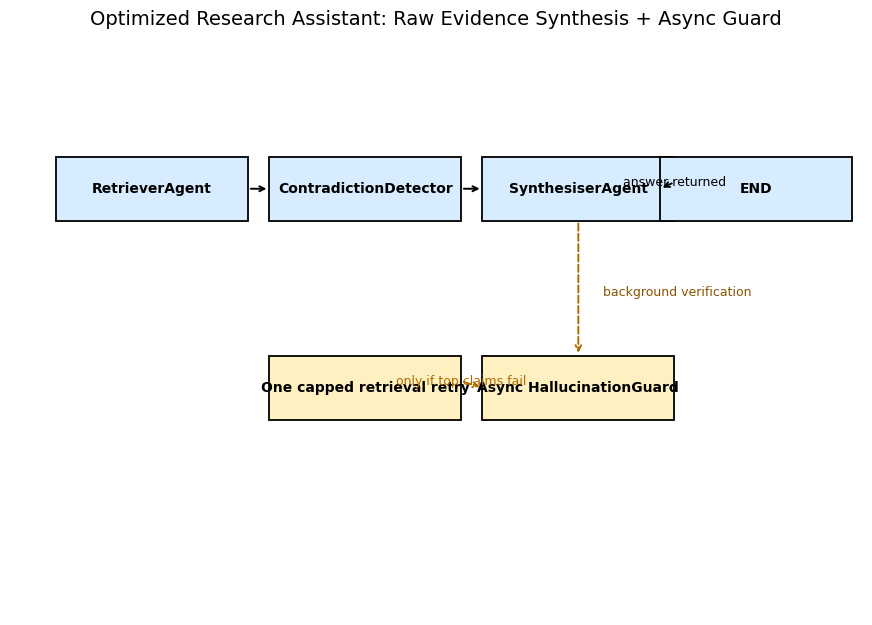

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(11, 8))
ax.set_aspect('equal')
ax.set_xlim(0, 12)
ax.set_ylim(0, 8)
ax.axis('off')

nodes = {
    "RetrieverAgent": (2, 6),
    "ContradictionDetector": (5, 6),
    "SynthesiserAgent": (8, 6),
    "END": (10.5, 6),
    "Async HallucinationGuard": (8, 3.2),
    "One capped retrieval retry": (5, 3.2),
}

for name, (x, y) in nodes.items():
    face = '#d7ecff' if y >= 6 else '#fff0c2'
    rect = patches.Rectangle((x - 1.35, y - 0.45), 2.7, 0.9, facecolor=face, edgecolor='black', linewidth=1.3)
    ax.add_patch(rect)
    ax.text(x, y, name, ha='center', va='center', fontsize=10, fontweight='bold')

def arrow(start, end, color='black', linestyle='-', label=None, yoffset=0.0):
    sx, sy = nodes[start]
    ex, ey = nodes[end]
    ax.annotate(
        label or '',
        xy=(ex - 1.35, ey + yoffset),
        xytext=(sx + 1.35, sy + yoffset),
        arrowprops=dict(facecolor=color, edgecolor=color, lw=1.4, arrowstyle='->', linestyle=linestyle),
        ha='center', va='bottom', fontsize=9, color=color,
    )

arrow("RetrieverAgent", "ContradictionDetector")
arrow("ContradictionDetector", "SynthesiserAgent")
arrow("SynthesiserAgent", "END", label='answer returned')

ax.annotate(
    '',
    xy=(8, 3.65),
    xytext=(8, 5.55),
    arrowprops=dict(facecolor='#b36b00', edgecolor='#b36b00', lw=1.4, arrowstyle='->', linestyle='--'),
)
ax.text(8.35, 4.55, 'background verification', fontsize=9, color='#8a5300', va='center')
arrow("One capped retrieval retry", "Async HallucinationGuard", color='#b36b00', linestyle='--', label='only if top claims fail')

plt.title('Optimized Research Assistant: Raw Evidence Synthesis + Async Guard', fontsize=14, pad=16)
plt.savefig('pipeline_architecture.png', bbox_inches='tight')
plt.show()


In [11]:
%%writefile research_streamlit_app.py
import os
import tempfile

import pandas as pd
import streamlit as st

from research_assistant_core import CorpusBuilder, LangGraphResearchAssistant


st.set_page_config(page_title="Agentic Research Assistant", layout="wide")

if "messages" not in st.session_state:
    st.session_state.messages = []
if "last_state" not in st.session_state:
    st.session_state.last_state = None
if "assistant" not in st.session_state:
    st.session_state.assistant = None
if "research_note" not in st.session_state:
    st.session_state.research_note = ""


def refresh_guard_if_ready():
    state = st.session_state.last_state
    assistant = st.session_state.assistant
    if not state or assistant is None:
        return
    future = state.get("guard_future")
    if future is not None and future.done() and state.get("guard", {}).get("status") == "PENDING":
        assistant.await_guard(state)
        st.session_state.research_note = state.get("final_answer", st.session_state.research_note)


refresh_guard_if_ready()

left, center, right = st.columns([1, 2, 1], gap="large")

with left:
    st.subheader("Corpus")
    uploads = st.file_uploader("PDFs", type=["pdf"], accept_multiple_files=True)
    arxiv_query = st.text_input("arXiv search", value="document layout understanding")
    max_results = st.slider("arXiv papers", min_value=1, max_value=30, value=10)
    max_pages = st.slider("PDF pages per arXiv paper", min_value=2, max_value=30, value=12)
    load_llm = st.checkbox("Load Phi-3-mini", value=True)
    load_nli = st.checkbox("Load DeBERTa NLI guard", value=True)

    if st.button("Build / Update Index", type="primary"):
        with st.spinner("Building corpus and indexes..."):
            tmpdir = tempfile.mkdtemp(prefix="research_pdfs_")
            for upload in uploads or []:
                path = os.path.join(tmpdir, upload.name)
                with open(path, "wb") as f:
                    f.write(upload.getbuffer())

            corpus = CorpusBuilder()
            local_count = corpus.add_pdf_folder(tmpdir)
            arxiv_count = corpus.fetch_arxiv(arxiv_query, max_results=max_results, max_pages=max_pages)
            corpus.build_index()
            st.session_state.assistant = LangGraphResearchAssistant(
                corpus=corpus,
                load_llm=load_llm,
                load_nli=load_nli,
                top_k=10,
                guard_threshold=0.55,
            )
            st.success(f"Indexed {len(corpus.chunks)} chunks ({local_count} local, {arxiv_count} arXiv).")


with center:
    st.subheader("Research Chat")
    for message in st.session_state.messages:
        with st.chat_message(message["role"]):
            st.markdown(message["content"])

    prompt = st.chat_input("Ask a research question...")
    if prompt:
        st.session_state.messages.append({"role": "user", "content": prompt})
        with st.chat_message("user"):
            st.markdown(prompt)

        if st.session_state.assistant is None:
            response = "Build the index first from the left panel."
        else:
            with st.spinner("Retrieving and synthesising raw evidence..."):
                state = st.session_state.assistant.run(prompt, wait_for_guard=False)
                st.session_state.last_state = state
                response = state["final_answer"]
                st.session_state.research_note = response

        st.session_state.messages.append({"role": "assistant", "content": response})
        with st.chat_message("assistant"):
            st.markdown(response)

    state = st.session_state.last_state
    if state and state.get("guard", {}).get("status") == "PENDING":
        if st.button("Refresh grounding metrics"):
            with st.spinner("Finishing claim-level guard verification..."):
                st.session_state.assistant.await_guard(state)
                st.session_state.research_note = state["final_answer"]
                st.rerun()

    if st.session_state.research_note:
        st.download_button(
            "Download research note",
            data=st.session_state.research_note,
            file_name="research_note.md",
            mime="text/markdown",
        )


with right:
    st.subheader("Sources")
    state = st.session_state.last_state
    if state:
        source_rows = []
        for i, chunk in enumerate(state.get("retrieved_chunks", []), start=1):
            meta = chunk["source"]
            source_rows.append(
                {
                    "rank": i,
                    "paper": meta.get("paper_title"),
                    "year": meta.get("year"),
                    "score": round(chunk.get("score", 0.0), 4),
                    "chunk_id": meta.get("chunk_id"),
                }
            )
        st.dataframe(pd.DataFrame(source_rows), use_container_width=True, hide_index=True)

        timings = state.get("timings", {})
        if timings:
            st.subheader("Latency")
            st.metric("Answer ready", f"{timings.get('time_to_first_token_seconds', 0.0):.2f}s")
            st.metric("Synthesis", f"{timings.get('synthesis_latency_seconds', 0.0):.2f}s")
            if "guardrail_latency_seconds" in timings:
                st.metric("Guardrail", f"{timings.get('guardrail_latency_seconds', 0.0):.2f}s")

        st.subheader("Confidence")
        guard = state.get("guard", {})
        if guard.get("status") == "PENDING":
            st.info("Claim verification is still running. Refresh grounding metrics when ready.")
        checks = guard.get("claim_checks", [])
        for check in checks:
            conf = float(check.get("grounding_confidence", check.get("confidence", 0.0)))
            st.progress(min(max(conf, 0.0), 1.0), text=f"{check['status']} - {conf:.2f}")
            st.caption(check["claim"])

        if st.button("Show contradictions"):
            contradictions = state.get("contradictions", [])
            if contradictions:
                for c in contradictions:
                    st.markdown(
                        f"<div style='color:#b00020; font-weight:600'>{c['message']} "
                        f"(score={c['score']:.2f})</div>",
                        unsafe_allow_html=True,
                    )
            else:
                st.info("No high-confidence contradictions detected.")
    else:
        st.caption("Run a question to populate sources and confidence scores.")


Writing research_streamlit_app.py


## Retrieval Breakdown Visualization

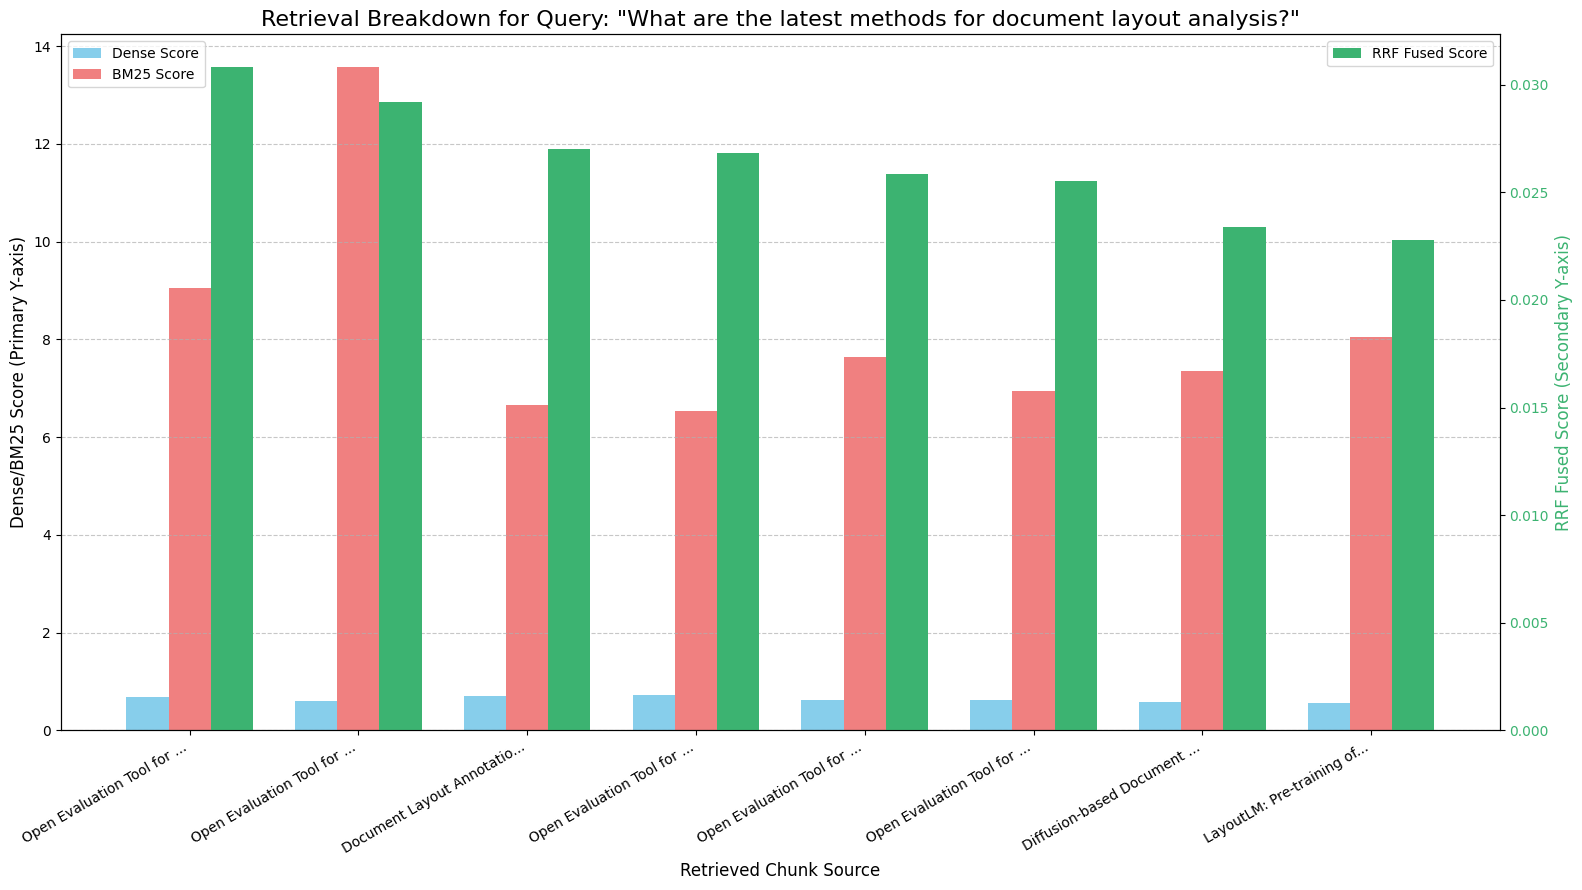

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Extract data from retrieved_chunks in the 'state' variable
plot_data = []
for i, chunk in enumerate(state["retrieved_chunks"]):
    title = chunk["source"]["paper_title"]
    # Truncate title for better readability on the x-axis
    truncated_title = (title[:25] + '...') if len(title) > 28 else title
    plot_data.append({
        "paper_title_truncated": truncated_title,
        "dense_score": chunk["dense_score"],
        "bm25_score": chunk["bm25_score"],
        "rrf_score": chunk["score"],
    })

df_plot = pd.DataFrame(plot_data)

# Create the figure and primary axis
fig, ax1 = plt.subplots(figsize=(16, 9))

# Number of chunks for x-axis positioning
n_chunks = len(df_plot)
x = np.arange(n_chunks)
bar_width = 0.25 # Width of each individual bar within a group

# Plot Dense Score bars on ax1 (primary y-axis)
rects1 = ax1.bar(x - bar_width, df_plot['dense_score'], bar_width, label='Dense Score', color='skyblue')

# Plot BM25 Score bars on ax1 (primary y-axis)
rects2 = ax1.bar(x, df_plot['bm25_score'], bar_width, label='BM25 Score', color='lightcoral')

ax1.set_ylabel('Dense/BM25 Score (Primary Y-axis)', fontsize=12)
ax1.set_xticks(x) # Set tick locations at the center of the bar groups
ax1.set_xticklabels(df_plot['paper_title_truncated'], rotation=30, ha='right')
ax1.set_xlabel('Retrieved Chunk Source', fontsize=12)
ax1.set_title(f'Retrieval Breakdown for Query: "{query}"', fontsize=16)
ax1.legend(loc='upper left')

# Create a secondary y-axis (ax2) for rrf_score
ax2 = ax1.twinx()

# Plot RRF Fused Score bars on ax2 (secondary y-axis)
rects3 = ax2.bar(x + bar_width, df_plot['rrf_score'], bar_width, label='RRF Fused Score', color='mediumseagreen')

ax2.set_ylabel('RRF Fused Score (Secondary Y-axis)', color='mediumseagreen', fontsize=12)
ax2.tick_params(axis='y', labelcolor='mediumseagreen')
ax2.legend(loc='upper right')

# Add grid for readability to the primary axis
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Ensure all elements fit within the figure area
plt.tight_layout()

# Save the figure
plt.savefig('retrieval_breakdown.png')

# Display the plot
plt.show()

## 10. Launch the Demo

Start the Streamlit app from inside Colab. When Streamlit tunneling is unavailable, use the direct notebook query cell below; it exercises the same non-blocking assistant path.


In [19]:
# Launch Streamlit inside Colab. If this fails, use the direct notebook query below.
!streamlit run research_streamlit_app.py --server.port 8501 --server.headless true >/content/streamlit.log 2>&1 &

try:
    from google.colab import output
    # Use serve_kernel_port_as_iframe as suggested for potentially better compatibility
    output.serve_kernel_port_as_iframe(8501)
except Exception:
    print("If you are not in Colab, open http://localhost:8501")
    print("If Streamlit does not open, run the next cell to query the assistant directly.")

<IPython.core.display.Javascript object>

## 11. Interactive Notebook Query Interface

This section provides an interactive interface for querying the research assistant directly within the notebook, serving as a faster alternative to the Streamlit app.

Enter your research question below and click 'Run Query' to see the assistant's response, retrieved sources, and claim verification results.

## 12. Gradio Interactive Interface

Let's create a Gradio interface as an alternative to the Streamlit app for a more streamlined in-notebook demonstration. This interface will allow you to query the research assistant and visualize its output directly.

In [20]:
!pip install gradio -q

In [24]:
import gradio as gr
import pandas as pd
import re

def gradio_run_assistant(query_text):
    if not query_text:
        return "Please enter a query.", "", None, None # Return empty string for confidence, None for dataframes

    state = assistant.run(query_text, wait_for_guard=False)
    assistant.await_guard(state)

    verified_answer_raw = state["final_answer"]
    guard = state.get("guard", {})
    checks = guard.get("claim_checks", [])

    # Extract Overall Grounding Confidence line and remove it from the raw answer
    overall_confidence_match = re.search(r"Overall grounding confidence: (.*)", verified_answer_raw)
    overall_confidence_value = "Pending" # Default if not found
    if overall_confidence_match:
        overall_confidence_value = overall_confidence_match.group(1)
        # Remove this line from the raw answer for further processing
        verified_answer_raw = verified_answer_raw.replace(overall_confidence_match.group(0), "").strip()

    # Prepare a prominent Markdown for overall confidence
    overall_confidence_markdown = f"### Overall Grounding Confidence: **{overall_confidence_value}**"

    # Split the raw answer into sections using regex and format with Markdown
    # Add a newline before the section markers to ensure consistent splitting
    sections_raw = re.split(r"\n\n\[(ANSWER|EVIDENCE|GAPS|CONTRADICTIONS|GROUNDING CHECK|SOURCES)\]\n", verified_answer_raw)

    formatted_response_parts = []
    if sections_raw[0].strip(): # Handle any initial text before the first recognized section
        formatted_response_parts.append(sections_raw[0].strip())

    for i in range(1, len(sections_raw), 2):
        section_type = sections_raw[i]
        section_content = sections_raw[i+1].strip()

        if section_type == "GROUNDING CHECK":
            # Summarize grounding checks for the markdown output
            if not checks:
                summary_str = "No verifiable claims were extracted or NLI guard is disabled."
            else:
                supported_count = sum(1 for c in checks if c.get("status") == "SUPPORTED")
                partial_count = sum(1 for c in checks if c.get("status") == "PARTIALLY_SUPPORTED")
                unverified_count = sum(1 for c in checks if c.get("status") == "UNVERIFIED")
                total_claims = len(checks)

                summary_str = f"- **Total Claims:** {total_claims}\n" \
                              f"- **Supported:** {supported_count}\n" \
                              f"- **Partially Supported:** {partial_count}\n" \
                              f"- **Unverified:** {unverified_count}\n" \
                              f"*(See 'Claim Grounding Checks' table below for details)*"
            formatted_response_parts.append(f"## {section_type}\n{summary_str}")
        else:
            # For other sections, just apply the heading and keep content
            formatted_response_parts.append(f"## {section_type}\n{section_content}")

    formatted_response = "\n\n".join(formatted_response_parts).strip()

    # Prepare retrieved sources DataFrame
    sources_df = pd.DataFrame([
        {
            "rank": i + 1,
            "paper_title": c["source"]["paper_title"],
            "year": c["source"]["year"],
            "rrf_score": f"{c["score"]:.4f}", # Format score for display
            "dense_score": f"{c["dense_score"]:.4f}",
            "bm25_score": f"{c["bm25_score"]:.4f}",
            "source_url": c["source"]["source_url"],
        }
        for i, c in enumerate(state["retrieved_chunks"])
    ])

    # Prepare grounding checks DataFrame
    guard_df = pd.DataFrame(checks)
    if guard_df.empty:
        guard_df = pd.DataFrame([{"Status": "No verifiable claims extracted or NLI guard disabled."}])
    else:
        # Format specific numerical columns for better readability (2 decimal places)
        for col in ['confidence', 'grounding_confidence', 'p_entailment', 'semantic_similarity']:
            if col in guard_df.columns:
                guard_df[col] = guard_df[col].apply(lambda x: f"{float(x):.2f}")
        guard_df = guard_df[['claim', 'status', 'confidence', 'grounding_confidence', 'p_entailment', 'semantic_similarity', 'best_source']]

    return formatted_response, overall_confidence_markdown, sources_df, guard_df


# Create Gradio interface
iface = gr.Interface(
    fn=gradio_run_assistant,
    inputs=gr.Textbox(lines=5, label="Enter your research question", placeholder="e.g., What are the latest methods for document layout analysis?"),
    outputs=[
        gr.Markdown(label="Assistant's Final Answer"),
        gr.Markdown(label="Overall Grounding Confidence"), # New output for prominent confidence
        gr.Dataframe(label="Retrieved Sources"),
        gr.Dataframe(label="Claim Grounding Checks")
    ],
    title="Agentic Research Assistant",
    description="Ask research questions and get grounded answers with source and claim verification."
)

# Launch the interface
iface.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://f99863d5c1d94eef8d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
[transformers] Both `max_new_tokens` (=700) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
[transformers] Both `max_new_tokens` (=700) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/tex

Keyboard interruption in main thread... closing server.

KeyboardInterrupt: 

In [18]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd

def run_assistant_and_display(query_text):
    with output_area:
        clear_output()
        print(f"Running query: {query_text}\n")

        # Run the assistant and get the initial answer
        state = assistant.run(query_text, wait_for_guard=False)
        print(state["final_answer"])

        # Await the guard for verified notes and display it
        assistant.await_guard(state)
        print("\n--- VERIFIED NOTE ---\n")
        print(state["final_answer"])

        # Display retrieved sources
        print("\n### Retrieved Sources\n")
        sources_df = pd.DataFrame([
            {
                "rank": i + 1,
                "paper_title": c["source"]["paper_title"],
                "year": c["source"]["year"],
                "rrf_score": c["score"],
                "dense_score": c["dense_score"],
                "bm25_score": c["bm25_score"],
                "source_url": c["source"]["source_url"],
            }
            for i, c in enumerate(state["retrieved_chunks"])
        ])
        display(sources_df)

        # Display grounding checks
        print("\n### Claim Grounding Checks\n")
        guard_df = pd.DataFrame(state["guard"]["claim_checks"])
        if not guard_df.empty:
            display(guard_df)
        else:
            print("No verifiable claims were extracted or NLI guard is disabled.")

# Create the text input widget
query_input = widgets.Textarea(
    value='',
    placeholder='Enter your research question here...',
    description='Query:',
    disabled=False,
    layout=widgets.Layout(width='auto', height='80px')
)

# Create the button widget
run_button = widgets.Button(
    description='Run Query',
    disabled=False,
    button_style='info',
    tooltip='Click to run the research query'
)

# Create an output widget to display results
output_area = widgets.Output()

# Define the button click event
def on_button_click(b):
    run_assistant_and_display(query_input.value)

run_button.on_click(on_button_click)

# Display the widgets
display(query_input, run_button, output_area)

Running query: How can retrieval-augmented generation reduce hallucinations in document QA?



[transformers] Both `max_new_tokens` (=700) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[ANSWER] - LayoutLLM significantly reduces document generation errors by incorporating layout-aware pre-training and fine-tuning strategies. [EVIDENCE] - LayoutLLM demonstrates the capability of interactive correction, which is crucial for refusing false-positive outputs and generating hints, as shown in the document. [GAPS] - The document does not provide specific metrics or comparisons to other models to quantify the reduction in generation errors. - There is no detailed explanation of how LayoutLLM's layout-aware pre-training and fine-tuning strategies specifically contribute to the reduction of errors. - The document does not discuss the limitations or potential areas for improvement in LayoutLLM's approach to reducing document generation errors.

[CONTRADICTIONS]
- OmniDocLayout: Towards Diverse Document Layout Generation via Coarse-to-Fine LLM Learning says jun Zhang, Kaixin Li, Zichen Wen, Zhong Li, Conghui He, Xuming Hu, et al.; A Simple yet Effective Layout Token in Large Lang

,rank,paper_title,year,rrf_score,dense_score,bm25_score,source_url
0,1,OmniDocLayout: Towards Diverse Document Layout...,2025,0.030415,0.446465,8.802065,http://arxiv.org/abs/2510.26213v2
1,2,A Simple yet Effective Layout Token in Large L...,2025,0.029010,0.429711,8.733829,http://arxiv.org/abs/2503.18434v1
2,3,OmniDocLayout: Towards Diverse Document Layout...,2025,0.028405,0.418183,9.241534,http://arxiv.org/abs/2510.26213v2
3,4,A Simple yet Effective Layout Token in Large L...,2025,0.025817,0.426771,6.152388,http://arxiv.org/abs/2503.18434v1
4,5,LayoutLLM: Layout Instruction Tuning with Larg...,2024,0.023615,0.414577,5.173828,http://arxiv.org/abs/2404.05225v1
5,6,Diffusion-based Document Layout Generation,2023,0.019203,0.401935,4.655728,http://arxiv.org/abs/2303.10787v1
6,7,A Simple yet Effective Layout Token in Large L...,2025,0.018425,0.390809,4.729882,http://arxiv.org/abs/2503.18434v1
7,8,Enhancing Visually-Rich Document Understanding...,2023,0.016393,0.452691,2.594838,http://arxiv.org/abs/2308.07777v1



### Claim Grounding Checks



,claim_rank,claim,clean_claim,confidence,grounding_confidence,p_entailment,semantic_similarity,status,best_source,nli_available
0,1,- There is no detailed explanation of how Layo...,There is no detailed explanation of how Layout...,0.280414,0.280414,0.000639,0.799996,UNVERIFIED,{'paper_title': 'LayoutLLM: Layout Instruction...,True
1,2,- The document does not discuss the limitation...,The document does not discuss the limitations ...,0.265951,0.265951,0.000115,0.759645,UNVERIFIED,{'paper_title': 'LayoutLLM: Layout Instruction...,True


In [14]:
# Direct notebook fallback when Streamlit is unavailable.
# This returns the answer immediately, then appends guard metrics when you await them.
query = "How can retrieval-augmented generation reduce hallucinations in document QA?"
state = assistant.run(query, wait_for_guard=False)
print(state["final_answer"])

# Later, or immediately for a complete research note:
assistant.await_guard(state)
print("\n\n--- VERIFIED NOTE ---\n")
print(state["final_answer"])


[transformers] Both `max_new_tokens` (=700) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[ANSWER] - LayoutLLM significantly reduces document generation errors by incorporating layout-aware pre-training and fine-tuning strategies. [EVIDENCE] - LayoutLLM demonstrates the capability of interactive correction, which is crucial for refusing false-positive outputs and generating hints, as shown in the document. [GAPS] - The document does not provide specific metrics or comparisons to other models to quantify the reduction in generation errors. - There is no detailed explanation of how LayoutLLM's layout-aware pre-training and fine-tuning strategies specifically contribute to the reduction of errors. - The document does not discuss the limitations or potential areas for improvement in LayoutLLM's approach to reducing document generation errors.

[CONTRADICTIONS]
- OmniDocLayout: Towards Diverse Document Layout Generation via Coarse-to-Fine LLM Learning says jun Zhang, Kaixin Li, Zichen Wen, Zhong Li, Conghui He, Xuming Hu, et al.; A Simple yet Effective Layout Token in Large Lang

## 13. Visualize Performance Results


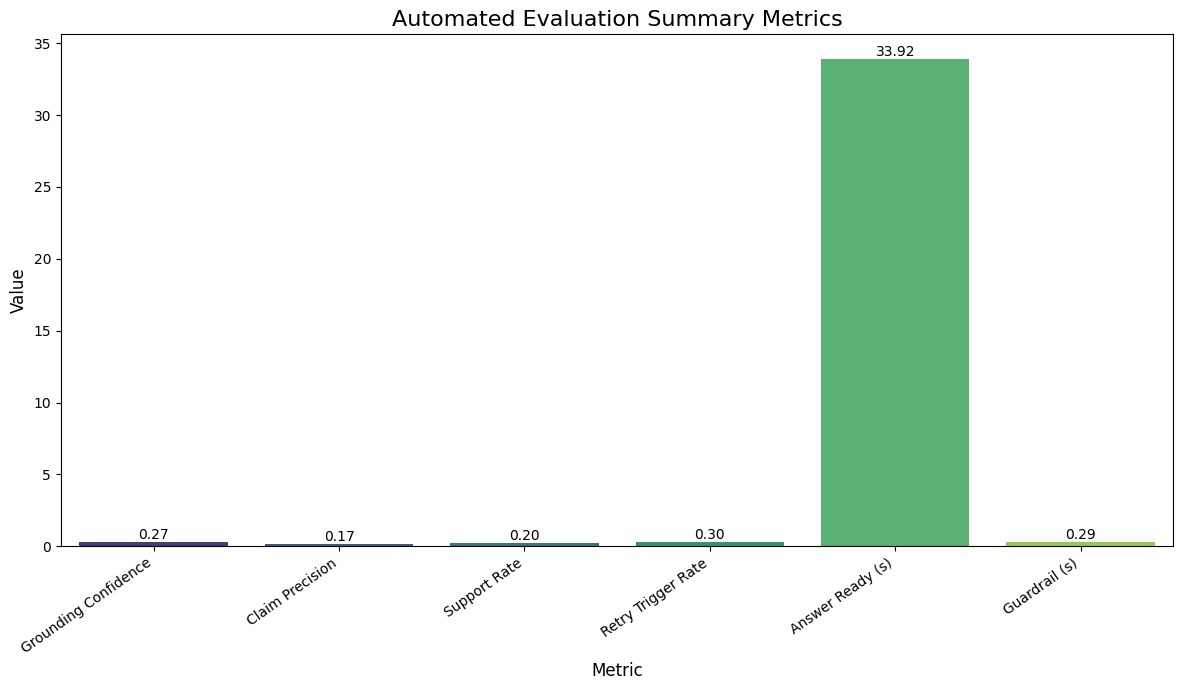

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

summary_series = pd.Series(summary)

metrics_to_plot = [
    'mean_faithfulness_score',
    'mean_claim_precision',
    'mean_claim_support_rate',
    'retry_trigger_rate',
    'mean_time_to_first_token_seconds',
    'mean_guardrail_latency_seconds',
]

metric_labels = {
    'mean_faithfulness_score': 'Grounding Confidence',
    'mean_claim_precision': 'Claim Precision',
    'mean_claim_support_rate': 'Support Rate',
    'retry_trigger_rate': 'Retry Trigger Rate',
    'mean_time_to_first_token_seconds': 'Answer Ready (s)',
    'mean_guardrail_latency_seconds': 'Guardrail (s)',
}

plot_df = pd.DataFrame({
    'Metric': [metric_labels[m] for m in metrics_to_plot],
    'Value': [summary_series.get(m, 0.0) for m in metrics_to_plot]
})

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x='Metric', y='Value', data=plot_df, palette='viridis', hue='Metric', legend=False, ax=ax)
ax.set_title('Automated Evaluation Summary Metrics', fontsize=16)
ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
plt.xticks(rotation=35, ha='right')

for index, row in plot_df.iterrows():
    ax.text(index, row['Value'], f"{row['Value']:.2f}", color='black', ha='center', va='bottom')

plt.tight_layout()
plt.show()


## 14. Evaluation Dashboard


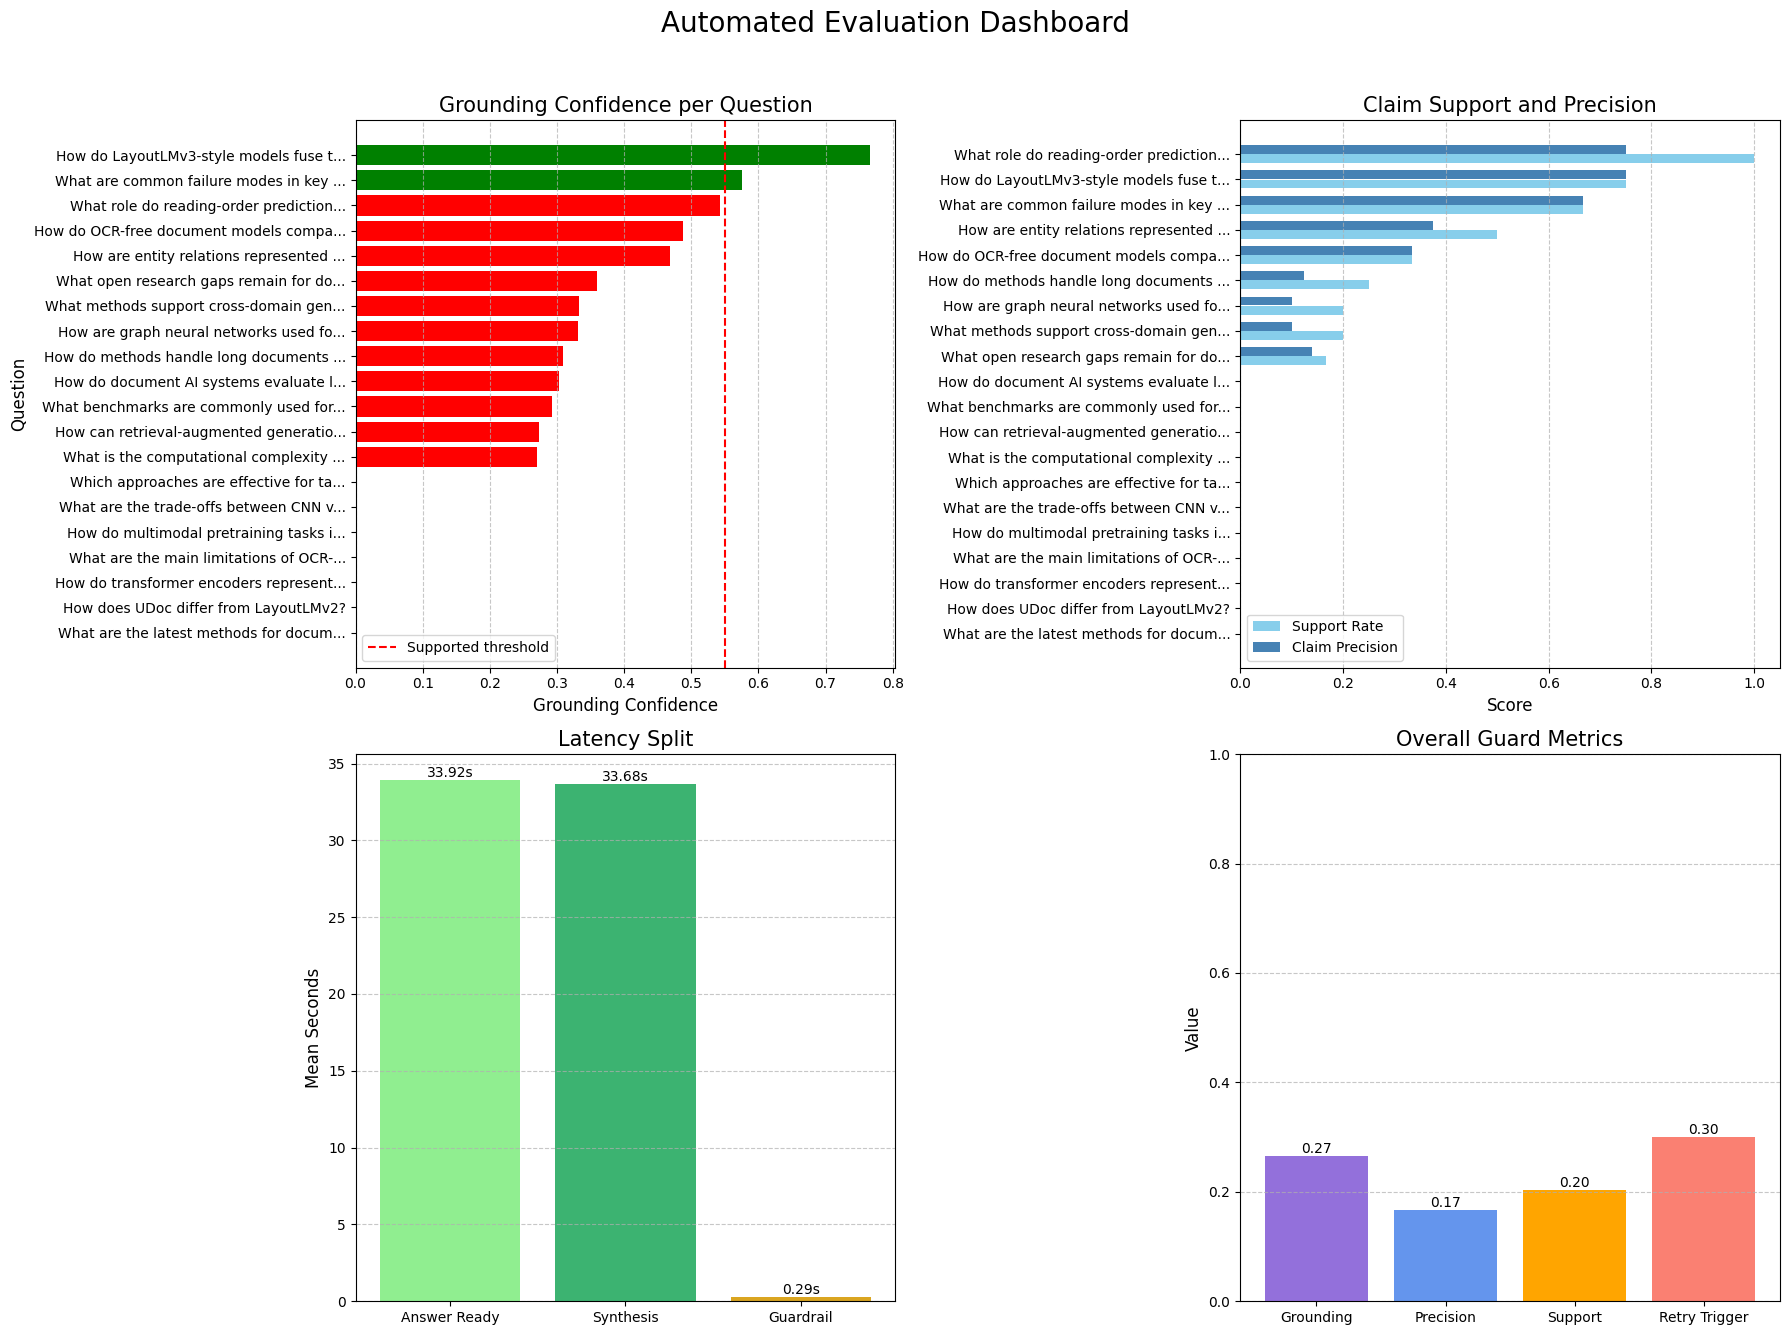


Summary Metrics:
Mean Grounding Confidence: 0.27
Mean Claim Precision: 0.17
Mean Claim Support Rate: 0.20
Retry Trigger Rate: 0.30
Mean Answer-Ready Latency: 33.92s
Mean Guardrail Latency: 0.29s


In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plot_eval_df = eval_df.copy()
plot_eval_df['truncated_question'] = plot_eval_df['question'].apply(lambda x: (x[:37] + '...') if len(x) > 40 else x)
plot_eval_df = plot_eval_df.sort_values(by='faithfulness_score', ascending=True)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Automated Evaluation Dashboard', fontsize=20)

# Top-left: calibrated grounding confidence.
ax1 = axes[0, 0]
faithfulness_colors = ['red' if score < 0.55 else 'green' for score in plot_eval_df['faithfulness_score']]
ax1.barh(plot_eval_df['truncated_question'], plot_eval_df['faithfulness_score'], color=faithfulness_colors)
ax1.axvline(0.55, color='red', linestyle='--', label='Supported threshold')
ax1.set_xlabel('Grounding Confidence', fontsize=12)
ax1.set_ylabel('Question', fontsize=12)
ax1.set_title('Grounding Confidence per Question', fontsize=15)
ax1.legend()
ax1.grid(axis='x', linestyle='--', alpha=0.7)

# Top-right: support and precision per question.
ax2 = axes[0, 1]
plot_eval_df = plot_eval_df.sort_values(by='claim_support_rate', ascending=True)
y = np.arange(len(plot_eval_df))
ax2.barh(y - 0.18, plot_eval_df['claim_support_rate'], height=0.35, label='Support Rate', color='skyblue')
ax2.barh(y + 0.18, plot_eval_df['claim_precision'], height=0.35, label='Claim Precision', color='steelblue')
ax2.set_yticks(y)
ax2.set_yticklabels(plot_eval_df['truncated_question'])
ax2.set_xlabel('Score', fontsize=12)
ax2.set_title('Claim Support and Precision', fontsize=15)
ax2.legend()
ax2.grid(axis='x', linestyle='--', alpha=0.7)

# Bottom-left: latency split.
ax3 = axes[1, 0]
latency_cols = ['time_to_first_token_seconds', 'synthesis_latency_seconds', 'guardrail_latency_seconds']
latency_means = [eval_df[c].mean() if c in eval_df else 0.0 for c in latency_cols]
ax3.bar(['Answer Ready', 'Synthesis', 'Guardrail'], latency_means, color=['lightgreen', 'mediumseagreen', 'goldenrod'])
ax3.set_ylabel('Mean Seconds', fontsize=12)
ax3.set_title('Latency Split', fontsize=15)
for index, value in enumerate(latency_means):
    ax3.text(index, value, f"{value:.2f}s", ha='center', va='bottom')
ax3.grid(axis='y', linestyle='--', alpha=0.7)

# Bottom-right: headline guard metrics.
ax4 = axes[1, 1]
summary_metrics = pd.DataFrame({
    'Metric': ['Grounding', 'Precision', 'Support', 'Retry Trigger'],
    'Value': [
        summary.get('mean_faithfulness_score', 0.0),
        summary.get('mean_claim_precision', 0.0),
        summary.get('mean_claim_support_rate', 0.0),
        summary.get('retry_trigger_rate', 0.0),
    ]
})
ax4.bar(summary_metrics['Metric'], summary_metrics['Value'], color=['mediumpurple', 'cornflowerblue', 'orange', 'salmon'])
ax4.set_ylabel('Value', fontsize=12)
ax4.set_title('Overall Guard Metrics', fontsize=15)
ax4.set_ylim(0, 1)
for index, row in summary_metrics.iterrows():
    ax4.text(index, row['Value'], f"{row['Value']:.2f}", color='black', ha='center', va='bottom', fontsize=10)
ax4.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig('evaluation_dashboard.png')
plt.show()

print("\nSummary Metrics:")
print(f"Mean Grounding Confidence: {summary.get('mean_faithfulness_score', 0.0):.2f}")
print(f"Mean Claim Precision: {summary.get('mean_claim_precision', 0.0):.2f}")
print(f"Mean Claim Support Rate: {summary.get('mean_claim_support_rate', 0.0):.2f}")
print(f"Retry Trigger Rate: {summary.get('retry_trigger_rate', 0.0):.2f}")
print(f"Mean Answer-Ready Latency: {summary.get('mean_time_to_first_token_seconds', 0.0):.2f}s")
print(f"Mean Guardrail Latency: {summary.get('mean_guardrail_latency_seconds', 0.0):.2f}s")
